# Assignment 5

## 1. Creating and Manipulating Arrays

In [92]:
import numpy as np
from matplotlib import pyplot as plt

### 1.1. Create two 2D arrays representing coordinates x, y on the cartesian plan

In [93]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)

In [94]:
xx,yy = np.meshgrid(x,y)

In [95]:
xx, yy

(array([[-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        ...,
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ]]),
 array([[-2.        , -2.        , -2.        , ..., -2.        ,
         -2.        , -2.        ],
        [-1.95959596, -1.95959596, -1.95959596, ..., -1.95959596,
         -1.95959596, -1.95959596],
        [-1.91919192, -1.91919192, -1.91919192, ..., -1.91919192,
         -1.91919192, -1.91919192],
        ...,
        [ 1.91919192,  1.91919192,  1.91919192, ...,  

In [96]:
xx.shape
yy.shape

(100, 100)

### 1.2. Visualize each 2D array using pcolormesh

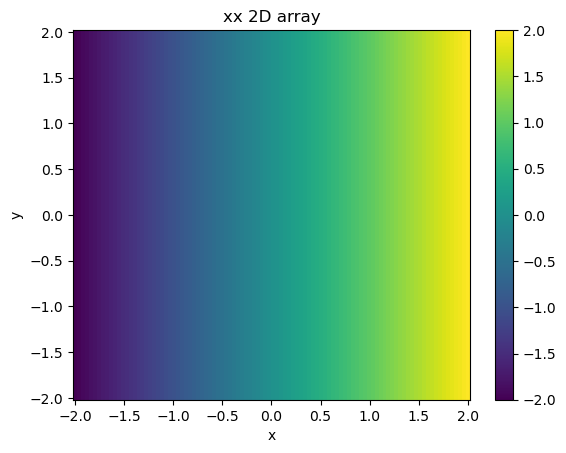

In [97]:
plt.figure()
plt.pcolormesh(x, y, xx)
plt.colorbar()
plt.title("xx 2D array")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

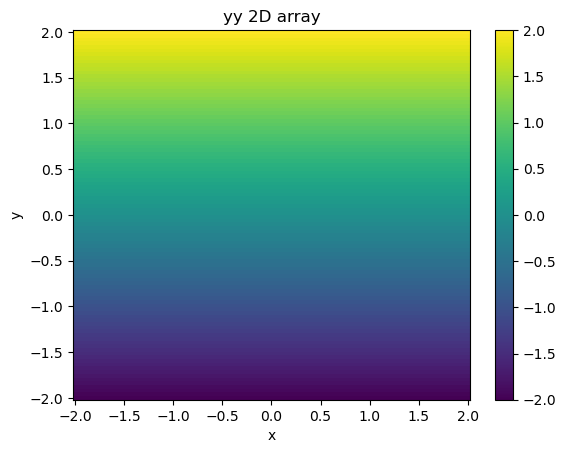

In [98]:
plt.figure()
plt.pcolormesh(x, y, yy)
plt.colorbar()
plt.title("yy 2D array")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### 1.3 From your cartesian coordinates, create polar coordinates

In [99]:
R = np.sqrt(xx**2 + yy**2)
Phi = np.arctan2(yy, xx)

In [100]:
R.shape
Phi.shape

(100, 100)

### 1.4 Visualize the polar coordinates on the 2D x|y plane using pcolormesh

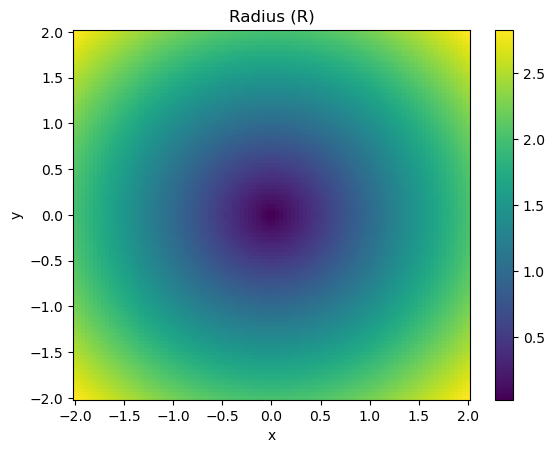

In [101]:
plt.figure()
plt.pcolormesh(x, y, R)
plt.colorbar()
plt.title("Radius (R)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

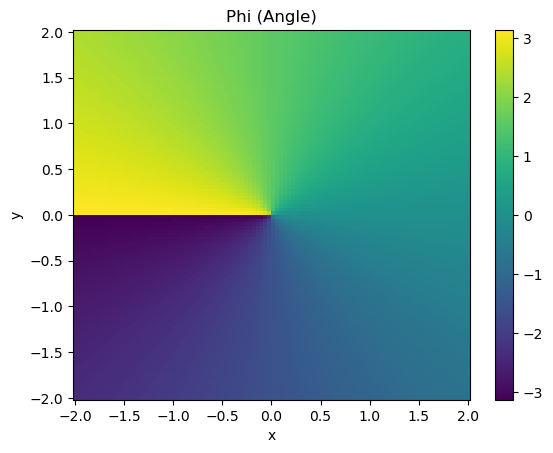

In [102]:
plt.figure()
plt.pcolormesh(x, y, Phi)
plt.colorbar()
plt.title("Phi (Angle)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### 1.5 Calculate the quantity and plot it x|y plane

In [104]:
f = (np.cos(4*R))**2 + (np.sin(4*Phi))**2

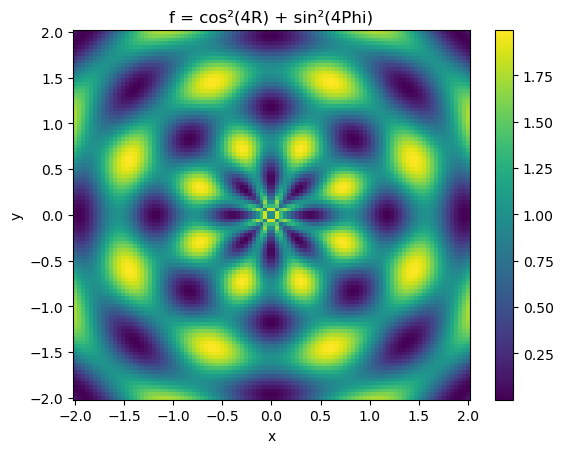

In [106]:
plt.figure()
plt.pcolormesh(x, y, f)
plt.colorbar()
plt.title("f = cos²(4R) + sin²(4Phi)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 2. Analyze ARGO Data

In [40]:
import pooch
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

Unzipping contents of '/home/iw2303/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip' to '/home/iw2303/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip'


['/home/iw2303/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/iw2303/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/iw2303/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/iw2303/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/iw2303/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/iw2303/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/iw2303/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

### 2.1 Load each data file as a numpy array

In [114]:
for f in files:
    if 'T.npy' in f:
        T = np.load(f)
    if 'S.npy' in f:
        S = np.load(f)
    if 'P.npy' in f:
        P = np.load(f)
    if 'levels.npy' in f:
        levels = np.load(f)
    if 'date.npy' in f:
        date = np.load(f)
    if 'lat.npy' in f:
        lat = np.load(f)
    if 'lon.npy' in f:
        lon = np.load(f) 

### 2.2 Examine the shapes of T, S and P compared to lon, lat, date and level. How do you think they are related?

In [116]:
print("T shape:", T.shape)
print("S shape:", S.shape)
print("P shape:", P.shape)

print("lat shape:", lat.shape)
print("lon shape:", lon.shape)
print("date shape:", date.shape)
print("levels shape:", levels.shape) 

print("I think the first number for T, S, and P (78) are the levels/depths, so I think T, S, and P, and levels are related there, and then I think the second number for T, S, and P is probably the date, since the 75 is shared between the T,S,P and the lat,lon, and date, but it is more likely if it is only 1 value that is would not be latitude or longitude alone, an be a date (which could then have its own latitude and longitude)")

T shape: (78, 75)
S shape: (78, 75)
P shape: (78, 75)
lat shape: (75,)
lon shape: (75,)
date shape: (75,)
levels shape: (78,)
I think the first number for T, S, and P (78) are the levels/depths, so I think T, S, and P, and levels are related there, and then I think the second number for T, S, and P is probably the date, since the 75 is shared between the T,S,P and the lat,lon, and date, but it is more likely if it is only 1 value that is would not be latitude or longitude alone, an be a date (which could then have its own latitude and longitude)


### 2.3 Make a plot for each column of data in T, S and P (three plots).

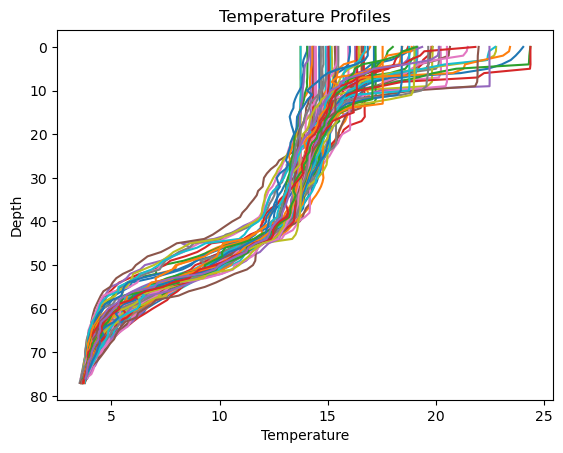

In [63]:
plt.figure()
plt.plot(T, levels)
plt.gca().invert_yaxis()
plt.title("Temperature Profiles")
plt.xlabel("Temperature")
plt.ylabel("Depth")
plt.show()

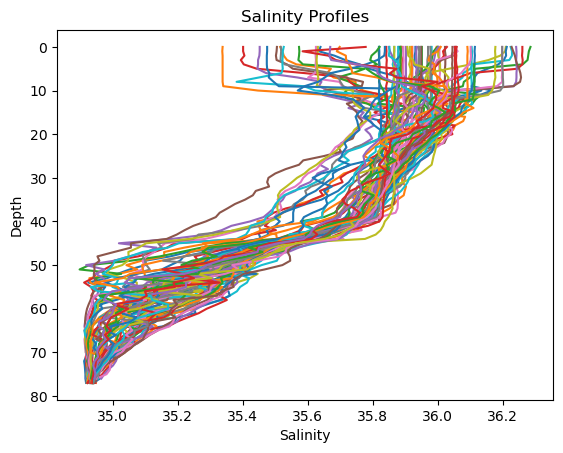

In [64]:
plt.figure()
plt.plot(S, levels)
plt.gca().invert_yaxis()
plt.title("Salinity Profiles")
plt.xlabel("Salinity")
plt.ylabel("Depth")
plt.show()

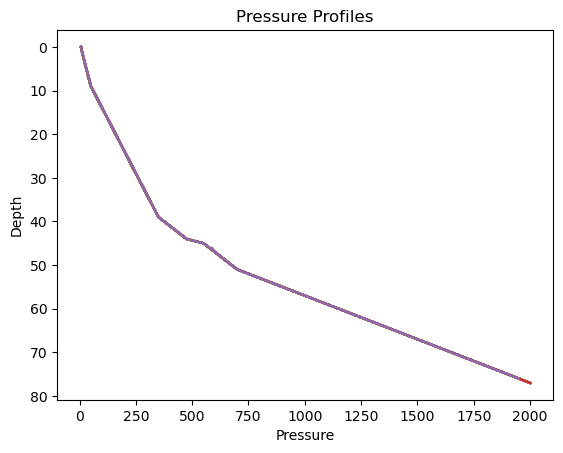

In [68]:
plt.figure()
plt.plot(P, levels)
plt.gca().invert_yaxis()
plt.title("Pressure Profiles")
plt.xlabel("Pressure")
plt.ylabel("Depth")
plt.show()

### 2.4 Compute the mean and standard deviation of each of T, S and P at each depth in level.

In [109]:
T_mean = np.mean(T, axis=1)
T_std = np.std(T, axis=1)

S_mean = np.mean(S, axis=1)
S_std = np.std(S, axis=1)

P_mean = np.mean(P, axis=1)
P_std = np.std(P, axis=1)

In [73]:
print("Temperature Mean at Each Depth:")
print(T_mean)
print("\nTemperature Standard Deviation at Each Depth:")
print(T_std)

print("\nSalinity Mean at Each Depth:")
print(S_mean)
print("\nSalinity Standard Deviation at Each Depth:")
print(S_std)

print("\nPressure Mean at Each Depth:")
print(P_mean)
print("\nPressure Standard Deviation at Each Depth:")
print(P_std)

Temperature Mean at Each Depth:
[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan 10.80430666 10.49702667
 10.1749066   9.83453334  9.48625332  9.19793334  8.66010666  8.12324001
  7.60221333  7.15289333  6.74250667  6.39543999  6.04598667  5.74538665
  5.48913333  5.26604001  5.08768     4.93479998  4.77769334  4.65368
  4.54237334  4.44274664  4.35933333         nan         nan         nan
         nan         nan         nan         nan         nan         nan]

Temperature Standard

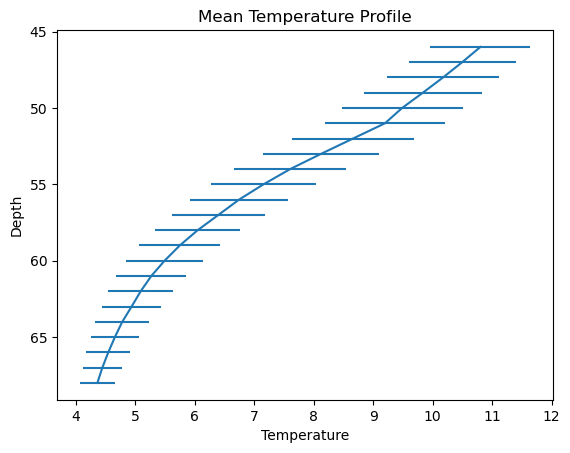

In [112]:
plt.figure()
plt.errorbar(T_mean, levels, xerr=T_std)
plt.gca().invert_yaxis()
plt.title("Mean Temperature Profile")
plt.xlabel("Temperature")
plt.ylabel("Depth")
plt.show()

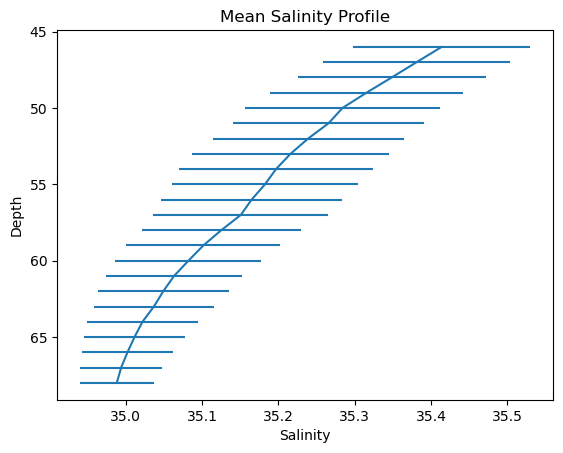

In [77]:
plt.figure()
plt.errorbar(S_mean, levels, xerr=S_std)
plt.gca().invert_yaxis()
plt.title("Mean Salinity Profile")
plt.xlabel("Salinity")
plt.ylabel("Depth")
plt.show()

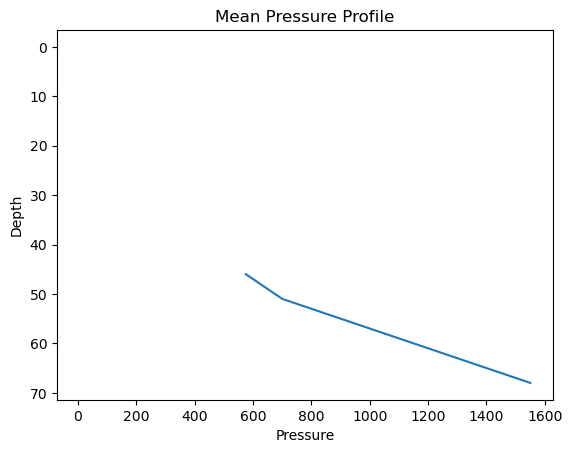

In [79]:
plt.figure()
plt.errorbar(P_mean, levels, xerr=P_std)
plt.gca().invert_yaxis()
plt.title("Mean Pressure Profile")
plt.xlabel("Pressure")
plt.ylabel("Depth")
plt.show()

### 2.6 Account For Missing Data

In [80]:
T_mean = np.nanmean(T, axis=1)
T_std = np.nanstd(T, axis=1)

S_mean = np.nanmean(S, axis=1)
S_std = np.nanstd(S, axis=1)

P_mean = np.nanmean(P, axis=1)
P_std = np.nanstd(P, axis=1)

In [81]:
print("Temperature Mean at Each Depth:")
print(T_mean)
print("\nTemperature Standard Deviation at Each Depth:")
print(T_std)

print("\nSalinity Mean at Each Depth:")
print(S_mean)
print("\nSalinity Standard Deviation at Each Depth:")
print(S_std)

print("\nPressure Mean at Each Depth:")
print(P_mean)
print("\nPressure Standard Deviation at Each Depth:")
print(P_std)

Temperature Mean at Each Depth:
[17.60172602 17.57223609 17.5145833  17.42326395 17.24943838 17.03730134
 16.76787661 16.44609588 16.17439195 16.04501356 15.65827023 15.4607296
 15.26114862 15.12489191 14.99133783 14.90160808 14.81990544 14.74535139
 14.66822971 14.585027   14.49732434 14.41904053 14.35412163 14.27102702
 14.19081082 14.11487838 14.04347293 13.98067566 13.90994595 13.83274319
 13.76139196 13.69836479 13.62335132 13.54185131 13.46647295 13.39395946
 13.32541891 13.25205403 13.18131082 13.10233782 12.89268916 12.67795943
 12.4649189  12.2178513  11.98270268 11.1281081  10.80430666 10.49702667
 10.1749066   9.83453334  9.48625332  9.19793334  8.66010666  8.12324001
  7.60221333  7.15289333  6.74250667  6.39543999  6.04598667  5.74538665
  5.48913333  5.26604001  5.08768     4.93479998  4.77769334  4.65368
  4.54237334  4.44274664  4.35933333  4.2653784   4.17290539  4.08902703
  3.99864865  3.92163514  3.85617567  3.78916217  3.72950001  3.66207691]

Temperature Standard 

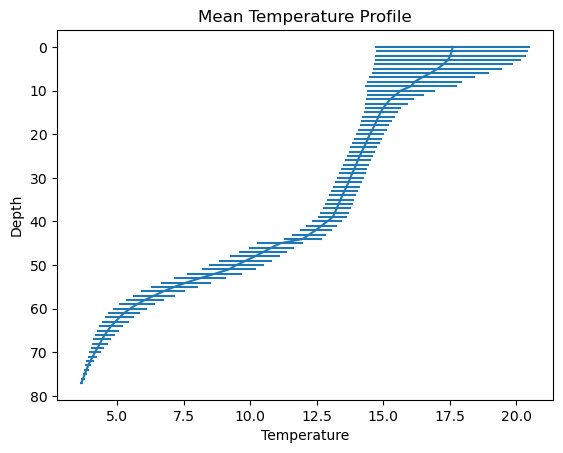

In [82]:
plt.figure()
plt.errorbar(T_mean, levels, xerr=T_std)
plt.gca().invert_yaxis()
plt.title("Mean Temperature Profile")
plt.xlabel("Temperature")
plt.ylabel("Depth")
plt.show()

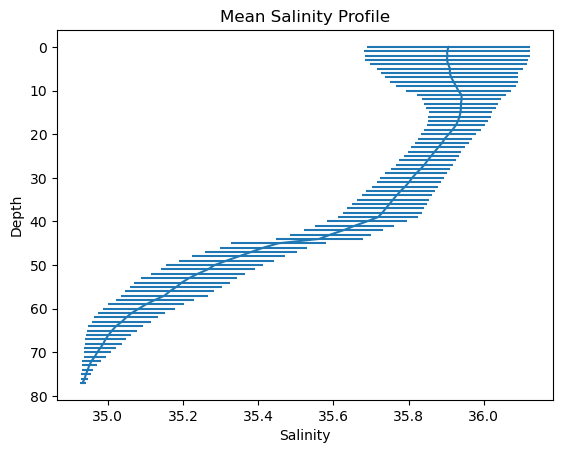

In [83]:
plt.figure()
plt.errorbar(S_mean, levels, xerr=S_std)
plt.gca().invert_yaxis()
plt.title("Mean Salinity Profile")
plt.xlabel("Salinity")
plt.ylabel("Depth")
plt.show()

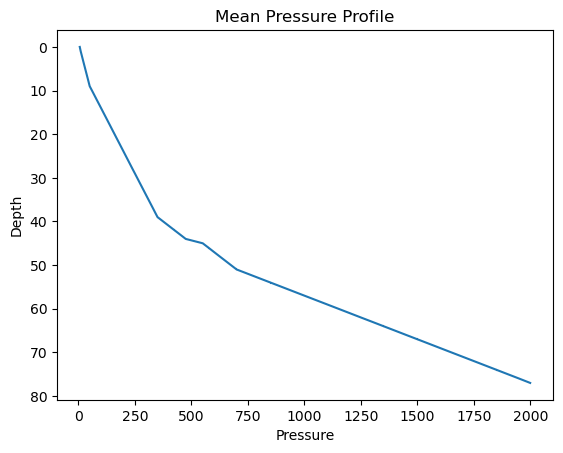

In [84]:
plt.figure()
plt.errorbar(P_mean, levels, xerr=P_std)
plt.gca().invert_yaxis()
plt.title("Mean Pressure Profile")
plt.xlabel("Pressure")
plt.ylabel("Depth")
plt.show()

### 2.7 Create a scatter plot of the lon, lat positions of the ARGO float.

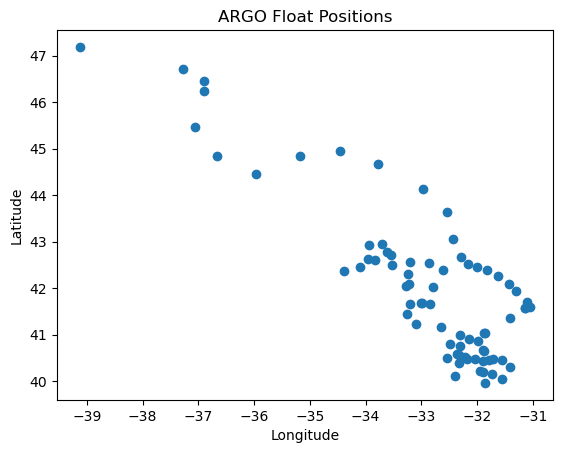

In [113]:
plt.scatter(lon, lat)
plt.title("ARGO Float Positions")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()